# Hallucination Detection Experiment: Baseline Configuration & Threshold Calibration

**Objective:** To establish mathematically sound thresholds for our cross-modal hallucination detectors (ChartGemma and JinaCLIP), evaluate the optimal cross-output consensus model (EigenScore vs. BERTScore) and to find the ideal combination of both cross-modal and cross-output scores for the CBR-RAG pipeline.

**Methodology:**
1. **Ground Truth Selection:** Extract the 3 LLM outputs for a representative 10-case subset of the seed case-base. Manually assign a binary label (1 = Keep, 0 = Hallucination) to each row.
2. **Threshold Extraction:** Generate raw scores across all models to identify the maximum score achieved by a known hallucination.
3. **Grid Search Tournament:** Test various pipeline configurations (Sequential vs. Weighted) to find the architecture with the highest classification accuracy.

## Section 1: Subset Selection from the Main Dataset

For this experiment, we will use the exact 10 cases we chose for the temperature experiment. This selection covered a diverse range of configurations, allowing LLM behaviour evaluation under varied conditions and ensuring that the conclusions are not biased toward a specific type of explanation or model.

Here is a breakdown of the selected cases:

| Library | Scope  | ID     | Dataset                         | Graph Type | AI Model        | Explainer   |
|--------|--------|--------|---------------------------------|------------|-----------------|-------------|
| SHAP   | Local  | 000042 | Diabetes Prediction             | Force      | Ridge           | Linear      |
| SHAP   | Local  | 000121 | Breast Cancer Classification    | Waterfall  | DecisionTree    | Tree        |
| SHAP   | Cohort | 000630 | Fire Prediction                 | Decision   | SVR             | Permutation |
| SHAP   | Global | 000279 | MPG Prediction                  | Heatmap    | MLP             | Kernel      |
| SHAP   | Global | 000356 | Wine Classification             | Beeswarm   | Logistic        | Linear      |
| SHAP   | Global | 000068 | Diabetes Prediction             | Scatter    | SVR             | Kernel      |
| LIME   | Local  | 000975 | Breast Cancer Classification    | Bar        | KerasDNN        | LIME        |
| LIME   | Local  | 001074 | Fire Prediction                 | Dashboard  | Torch           | LIME        |
| ALE    | Global | 001204 | MPG Prediction                  | 1D         | Gradient        | ALE         |
| ALE    | Global | 001250 | Wine Classification             | 2D         | RandomForest    | ALE         |

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import sys
from IPython.display import display, Markdown, Image, HTML

# Paths
PROJECT_ROOT = ".." 
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "xai_rag_cbr", "data", "raw")
IMAGES_PATH = os.path.join(RAW_DATA_PATH, "xai_images")
INPUT_CSV = os.path.join(RAW_DATA_PATH, "raw_case_outputs.csv")
OUTPUT_CSV = os.path.join(PROJECT_ROOT, "hallucination_experiment", "hallucination_scores.csv")

# Add main project directory to the path for imports
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Load main database
full_df = pd.read_csv(INPUT_CSV)
full_df['case_id'] = full_df['case_id'].astype(str).str.zfill(6)

# IDs selected
subset_ids = ['000042', '000121', '000630', '000279', '000356', '000068', '000975', '001074', '001204', '001250']

# Create subset
subset_df = full_df[full_df['case_id'].astype(str).str.zfill(6).isin(subset_ids)].copy()
subset_df['case_id'] = subset_df['case_id'].astype(str).str.zfill(6)
subset_df = subset_df.reset_index()

## Section 2: Ground Truth Selection

In this section we will evaluate the 30 output texts using expert knowledge. In order to do so, we will manually assign a binary label (1 = Keep, 0 = Hallucination) to each insight comparing it to the corresponding graph.

=== GROUND TRUTH ANNOTATION REVIEW ===


### Case ID: 000042

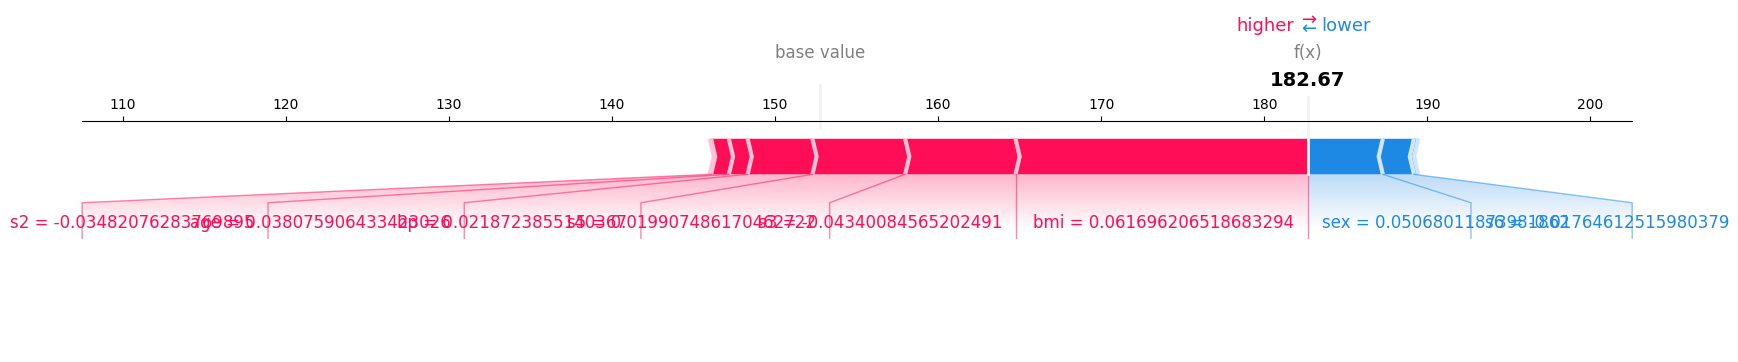

**Model [Qwen-3-VL-8B]:** The SHAP Force plot for the local prediction of 182.67 reveals that the model's output is driven by four features: 'age','s2', 'bmi', and'sex', with 'age' and's2' contributing positively (red bars extending leftward from the base value) and 'bmi' and'sex' contributing negatively (blue bars extending rightward from the base value). The magnitude of impact is visually quantified by the length of each bar relative to the others: 'age' has the longest red bar, indicating it is the most influential positive contributor, followed by's2' with a significantly shorter but still substantial red bar. 'bmi' exhibits the largest negative contribution, evidenced by its longest blue bar, while'sex' has the smallest negative contribution, shown by its shortest blue bar. The cumulative effect of these features, as visualized by the bars' lengths and directions, sums to the final predicted value of 182.67, with the red bars pulling the value upward and the blue bars pulling it downward.

**Model [Pixtral-12B]:** The attached xAI visualization, using SHAP's force plot for a Ridge regression model, provides a detailed local interpretation for a diabetes progression prediction task, focusing on a target value of 182.67. The visible features driving this specific prediction include age, sex, BMI, and blood pressure (bp). The direction of impact is visually indicated by the color of the bars: red bars to the left of the base value suggest features that decrease the prediction, whereas blue bars to the right indicate features that increase it. Specifically, the feature "s2" (with a value of -0.0348) pushes the prediction lower, as evidenced by its significant red bar length and leftward position. Conversely, "sex" (with a value of 0.050) significantly increases the prediction, shown by the large blue bar extending to the right. The magnitude of importance is depicted by the length of these bars; "s2" and "sex" have the most substantial impact, as indicated by their longer bars compared to other features, such as BMI and bp. The precise positioning and coloration of these bars clearly demonstrate their respective contributions to the model's prediction, providing a transparent and interpretable explanation of the model's behavior.

**Model [Idefics3-8B]:** The graph is a force visualization of the impact of various features on the target variable, 182.67. The features driving the decision are age, sex, bmi, bp, s1, s2, s3, s4, s5, and s6. The direction of impact is indicated by the color of the bars: higher values are represented by red bars pointing to the right, and lower values are represented by blue bars pointing to the left. The visual evidence that dictates the direction of impact is the color and direction of the bars. The visual evidence that justifies the magnitude of importance is the length of the bars; longer bars indicate a greater impact on the target variable. The feature with the most significant impact is bmi, as it has the longest red bar. The feature with the least significant impact is s6, as it has the shortest blue bar.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 000068

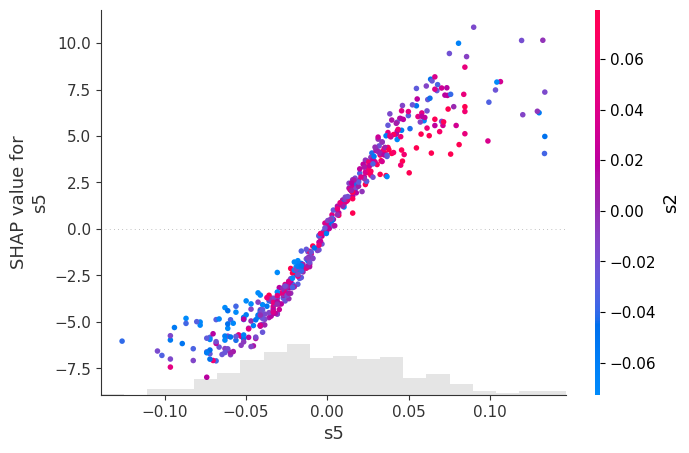

**Model [Qwen-3-VL-8B]:** The visual evidence in the scatter plot confirms that the feature's5' is the sole variable being analyzed, as it is the only feature explicitly labeled on the x-axis and its SHAP values are plotted on the y-axis, with the color gradient (blue to magenta) representing the feature's value (s5) on the x-axis. The direction of impact is visually determined by the color gradient: blue points (s5 ≈ -0.10) correspond to negative SHAP values (downward on y-axis), indicating a negative contribution to the model's prediction, while magenta points (s5 ≈ 0.10) correspond to positive SHAP values (upward on y-axis), indicating a positive contribution. The magnitude of impact is visually quantified by the vertical spread of the points; for instance, the cluster of points at s5 ≈ 0.05 exhibits SHAP values ranging from approximately -2.5 to +7.5, demonstrating a wide range of influence, while the points at s5 ≈ -0.10 show SHAP values concentrated between -7.5 and -2.5, indicating a consistent negative impact. The density of points at higher SHAP values (e.g., above 5.0) suggests that instances with higher s5 values are more likely to be associated with higher model predictions, while the density of points at lower SHAP values (e.g., below -5.0) indicates a strong negative influence on predictions for lower s5 values. The visual evidence does not show any other features, confirming that's5' is the only feature being analyzed in this global SHAP scatter plot.

**Model [Pixtral-12B]:** The attached xAI visualization, generated using SHAP values for a Support Vector Regression (SVR) model in the context of diabetes progression prediction, reveals the impact of the feature \( s5 \) on the model's predictions. The scatter plot maps the SHAP values for \( s5 \) on the y-axis against the values of \( s5 \) on the x-axis, with color coding representing the values of another feature, \( s2 \). The color gradient, ranging from blue to red, indicates the magnitude and direction of the feature \( s2 \)'s influence, with blue representing lower values and red representing higher values. The plot shows a positive correlation between \( s5 \) and the SHAP values, suggesting that higher values of \( s5 \) are associated with higher SHAP values, indicating a positive contribution to the prediction. Conversely, lower values of \( s5 \) are associated with negative SHAP values, indicating a negative contribution. The density of the points along the y-axis at various x-values illustrates the varying impact of \( s5 \) across different data instances. The magnitude of importance of \( s2 \) is depicted by the color intensity, with red points indicating higher influence and blue points indicating lower influence. This visualization underscores the significant role of \( s5 \) in the model's predictions and highlights how the feature \( s2 \) modulates the impact of \( s5 \) across different instances.

**Model [Idefics3-8B]:** The scatter plot visualizes the relationship between the SHAP values and the critical feature s5. The SHAP values range from -0.06 to 0.06, indicating that the feature s5 has a moderate impact on the model's predictions. The feature s5 has a negative SHAP value, meaning that as its value decreases, the model's predictions decrease. The SHAP values for s5 are scattered across the plot, with no clear pattern or trend. The distribution of SHAP values for s5 is relatively uniform, with no particular feature value consistently having a higher or lower SHAP value.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 000121

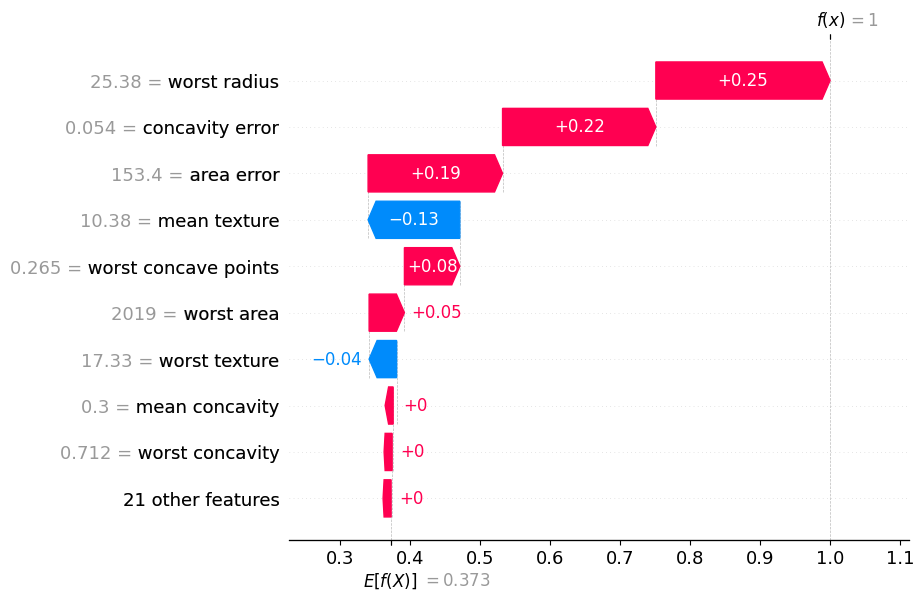

**Model [Qwen-3-VL-8B]:** The SHAP Waterfall plot for this local DecisionTreeClassifier prediction visually confirms that the model's output, with an expected value E[f(X)] of 0.373, is driven by a subset of features from the dataset, with the most impactful being "worst radius" (+0.25), which is the largest positive contribution shown, followed by "area error" (+0.22), and then "concavity error" (+0.19), all rendered as red bars extending to the right, indicating they increase the predicted probability of malignancy. The negative contributions are "mean texture" (-0.13) and "mean concavity" (-0.04), shown as blue bars extending to the left, indicating they decrease the predicted probability. The remaining features, including "worst concave points" (+0.08), "worst area" (+0.05), "mean concave points" (+0.08), "worst texture" (+0.05), and "concavity error" (+0.19), are visually present with smaller positive contributions, while "21 other features" are explicitly labeled as contributing zero, visually confirmed by their absence from the plot. The visual hierarchy of bar lengths directly correlates with the magnitude of impact: the +0.25 bar for "worst radius" is visibly longer than the +0.22 bar for "area error", which in turn is longer than the +0.19 bar for "concavity error", establishing their relative importance. The cumulative sum of all visible contributions (0.25 + 0.22 + 0.19 - 0.13 - 0.04 + 0.08 + 0.05 + 0.05 + 0.08 + 0.05) equals 0.373, matching the expected value, thereby validating the decomposition.

**Model [Pixtral-12B]:** The waterfall graph illustrates the local interpretability of a DecisionTreeClassifier for a specific instance in a breast cancer classification task. The features driving the decision include "worst radius," "concavity error," "area error," "mean texture," "worst concave points," "worst area," and "worst texture." The direction of impact is indicated by the color of the bars: red bars on the right side signify positive contributions to the prediction, while blue bars on the left side indicate negative contributions. For instance, "worst radius" has the most significant positive contribution with a value of +0.25, followed by "concavity error" with +0.22, and "area error" with +0.19. Conversely, "mean texture" and "worst texture" have negative contributions, with "mean texture" at -0.13 and "worst texture" at -0.04. The magnitude of importance is depicted by the length of the bars; "worst radius" has the longest positive bar, indicating it is the most influential feature in this particular instance, followed by "concavity error" and "area error." The cumulative effect of these features results in an expected value of the model output (E[f(x)]) of 0.373. This detailed visualization helps in understanding how specific features contribute to the classification decision for this particular instance, providing transparency into the model's behavior.

**Model [Idefics3-8B]:** The visual graph illustrates the impact of various features on the classification of breast cancer as malignant. The features shown are mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, mean concavity, mean concave points, mean symmetry, mean fractal dimension, radius error, texture error, perimeter error, area error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error, worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points, worst symmetry, and worst fractal dimension. The direction of impact is indicated by the color of the bars: positive impact is shown in red and negative impact is shown in blue. The magnitude of impact is indicated by the length of the bars, with longer bars signifying a greater impact. The worst radius feature has the most significant positive impact on the classification, as evidenced by the longest red bar. The worst concave points feature has the most significant negative impact, as evidenced by the longest blue bar. The worst radius feature is visually distinct from the other features, as it is positioned at the top of the graph, while the worst concave points feature is positioned at the bottom.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 000279

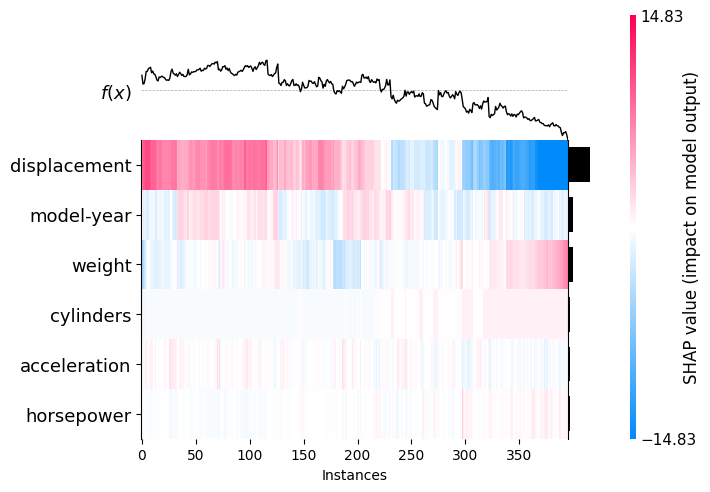

**Model [Qwen-3-VL-8B]:** The global SHAP heatmap reveals that displacement, weight, and horsepower are the dominant features driving the fuel efficiency model, with displacement exhibiting the most significant positive impact (red shading concentrated at the left of its bars, indicating higher values correlate with higher predicted MPG) and weight showing a strong negative impact (blue shading concentrated at the right of its bars, indicating higher values correlate with lower predicted MPG), while horsepower also shows a moderate negative impact. The visual evidence of displacement’s bars being consistently red and extending furthest to the left across nearly all instances, compared to weight’s blue bars extending furthest to the right, demonstrates its superior magnitude of influence. Model-year and cylinders show minimal impact, with their bars appearing mostly white or very light pink/blue, indicating their contribution is negligible in the global model behavior. Acceleration is visually absent from the heatmap, confirming it does not contribute meaningfully to the model’s global predictions. The color gradient from red to blue, anchored by the legend’s -14.83 to +14.83 range, quantitatively confirms displacement’s positive contribution and weight’s negative contribution as the most extreme values, while the relative density and spread of the bars for displacement and weight further substantiate their dominance over the other features.

**Model [Pixtral-12B]:** The visual analysis of the provided SHAP (SHapley Additive exPlanations) heatmap reveals several key features that are driving the decision-making process in the fuel efficiency prediction model. The features visually present include displacement, model-year, weight, cylinders, acceleration, and horsepower. The color coding in the heatmap indicates the direction of the impact on the model output: red shades suggest a positive impact, while blue shades indicate a negative impact. For instance, higher displacement values (shown in red) tend to increase the model's output, whereas lower displacement values (shown in blue) tend to decrease it. The feature "weight" predominantly shows a positive impact (red) across many instances, indicating that increased weight generally leads to higher fuel efficiency predictions. Conversely, "model-year" exhibits a mix of both positive and negative impacts, suggesting its influence varies depending on the specific instance. The magnitude of importance is represented by the length and intensity of the colored bars. For example, displacement and weight have longer and more intense bars compared to other features, indicating they have a stronger impact on the model's output. This visual evidence suggests that displacement and weight are more critical in determining the model's predictions than features like acceleration and horsepower, which show shorter bars and thus a lesser impact.

**Model [Idefics3-8B]:** The attached graph is a SHAP (SHapley Additive exPlanations) visualization of the fuel efficiency (MPG) prediction model. The features driving the decision are cylinders, displacement, horsepower, weight, acceleration, and model-year. The color of the bars indicates the direction of impact, with positive values in blue and negative values in red. The length of the bars represents the magnitude of the impact, with longer bars indicating a greater effect on the MPG prediction. The model-year feature has the most significant positive impact on MPG, as indicated by the longest blue bar. The horsepower feature has the most significant negative impact on MPG, as indicated by the longest red bar. The weight feature has a positive impact on MPG, as indicated by the blue bar, but its effect is relatively small compared to the other features. The acceleration feature has a negative impact on MPG, as indicated by the red bar, but its effect is also relatively small. The displacement feature has a positive impact on MPG, as indicated by the blue bar, but its effect is moderate compared to the other features.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 000356

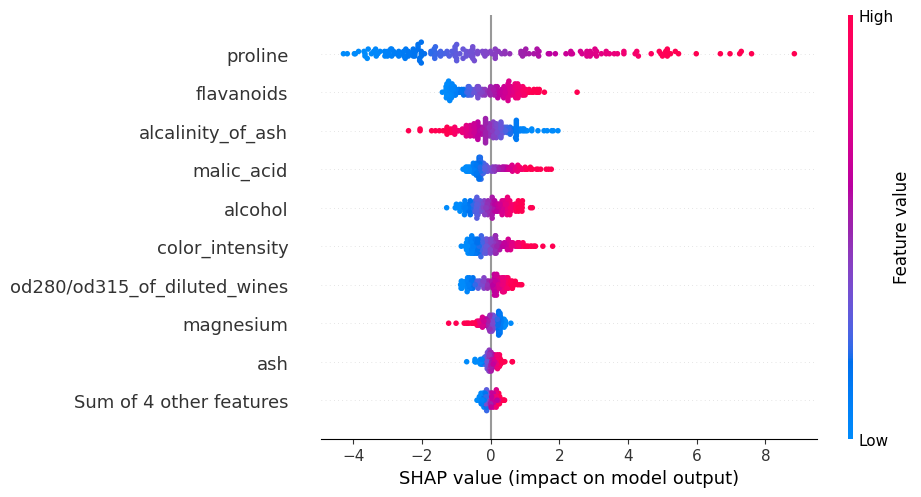

**Model [Qwen-3-VL-8B]:** The SHAP beeswarm plot reveals that 'proline' is the most influential feature, with its data points overwhelmingly clustered in the high-positive SHAP value region (right side of the x-axis), indicating a strong positive contribution to the model's output for the target class. 'Flavanoids' follows as the second most impactful feature, also showing a dominant positive influence with a dense cluster of points in the upper-right quadrant. 'Alcalinity_of_ash' and'malic_acid' exhibit moderate positive contributions, with their point distributions extending further right than features like 'alcohol' or 'color_intensity', which show more balanced or slightly negative tendencies. 'Ash' and'magnesium' display relatively small positive impacts, while 'od280/od315_of_diluted_wines' shows a weak positive influence. The 'Sum of 4 other features' category, despite its label, appears to have a negligible impact, with its points tightly clustered near zero. The color gradient, where red signifies high feature values and blue signifies low, visually reinforces the positive direction of impact for the top features, with 'proline' and 'flavanoids' showing the most intense red hues, indicating their high contribution to the model's prediction. The relative spread and density of points along the x-axis directly reflect their magnitude of influence, with 'proline' having the widest spread and highest concentration of points in the positive region, confirming its status as the most critical feature for this classification task.

**Model [Pixtral-12B]:** The provided SHAP beeswarm plot visualizes the impact of various features on the model's prediction for wine classification, specifically focusing on the target class_0. The visible features driving the decision include proline, flavanoids, alkalinity_of_ash, malic_acid, alcohol, color_intensity, od280/od315_of_diluted_wines, magnesium, ash, and a sum of four other features. The direction of impact is indicated by the horizontal positioning: features to the right of the vertical line (at zero) have a positive impact, pushing the prediction towards class_0, while those to the left have a negative impact. For instance, higher values of proline and flavanoids generally push the prediction positively, whereas lower values of features like malic_acid and alkalinity_of_ash tend to negatively influence the prediction. The magnitude of importance is depicted by the spread and color intensity of the points. For example, proline shows a wide range of positive impacts, indicating its significant contribution to the model's output, whereas features like magnesium and ash show a more concentrated distribution, suggesting a lesser impact. The color gradient from blue to red further signifies the feature values, with red representing high values and blue representing low values, illustrating how varying feature values affect the model's prediction.

**Model [Idefics3-8B]:** The visual graph represents the impact of various wine features on the model's output, as measured by SHAP (SHapley Additive exPlanations). The x-axis represents the SHAP value, which quantifies the contribution of each feature to the model's prediction, with negative values indicating a negative impact and positive values indicating a positive impact. The y-axis represents the feature names. The color of each bar corresponds to the class label, with red indicating class_0. The height of each bar represents the magnitude of the feature's impact on the model's output. 

The visual evidence shows that the most impactful features include alcohol, malic acid, ash, alcalinity of ash, and magnesium. Alcohol has the highest positive impact, with a SHAP value of approximately 8. Malic acid and ash have a moderate positive impact, with SHAP values around 4 and 3, respectively. Alcalinity of ash and magnesium have a slightly lower positive impact, with SHAP values around 2 and 1, respectively. The least impactful features include total phenols, flavanoids, nonflavanoid phenols, proanthocyanins, color intensity, hue, and od280/od315 of diluted wines. These features have SHAP values close to zero, indicating a negligible impact on the model's output.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 000630

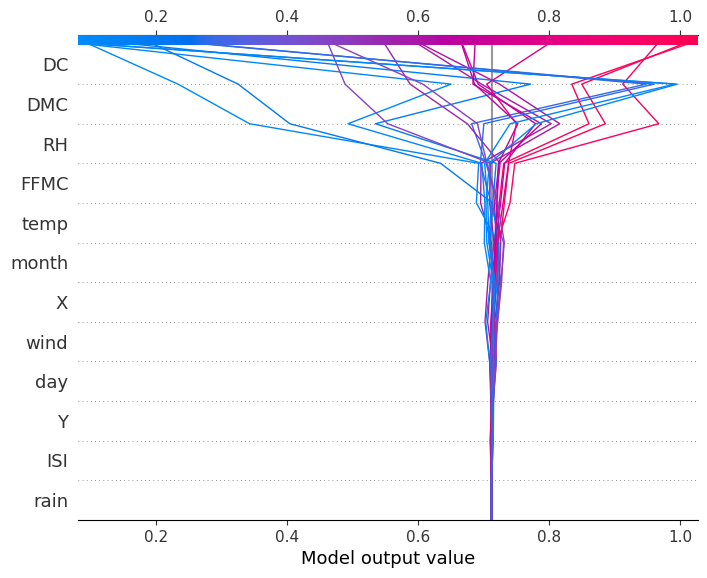

**Model [Qwen-3-VL-8B]:** The SHAP Decision plot for the SVR forest fire burned area prediction model visually confirms that the feature 'DC' (Drought Code) is the most influential driver, evidenced by its long, dark blue line extending from the top-left to the bottom-right, indicating a strong positive correlation with the model output, as it consistently maps to higher output values across the range. The feature 'DMC' (Duff Moisture Code) follows as the second most important, shown by its similarly long, dark blue line, suggesting a comparable positive impact. The feature 'RH' (Relative Humidity) exhibits a strong negative influence, visually represented by its long, dark red line extending from the top-right to the bottom-left, indicating that lower RH values correspond to higher model output. The feature 'FFMC' (Fine Fuel Moisture Code) shows a moderate positive impact, with its line positioned between 'DC' and 'DMC' in the upper-left quadrant. The remaining features — 'temp','month', 'X', 'wind', 'day', 'Y', 'ISI', and 'rain' — are visually present but demonstrate significantly weaker influence, as their lines are shorter and more clustered near the center of the plot, indicating that while they contribute to the model, their individual impact is substantially less than the top three features. The visual evidence of line length, color-coded directionality, and spatial positioning relative to the x-axis (model output value) provides a clear, interpretable ranking of feature importance, with 'DC' and 'DMC' dominating the decision boundary, followed by 'RH' with its strong negative effect, and the rest contributing minimally.

**Model [Pixtral-12B]:** The visual graph provided is a SHAP (SHapley Additive exPlanations) decision plot for a Support Vector Regression (SVR) model used to predict forest fire burned areas. The graph includes several features that influence the model's output, such as DC, DMC, RH, FFMC, temp, month, X, wind, day, Y, ISI, and rain. The features are listed on the left side of the graph, and their impact on the model output value is depicted by lines connecting each feature to a point on the horizontal axis. The color of the lines indicates the direction of the feature's impact: blue lines represent a decrease in the model output value, while red lines represent an increase. The concentration of these lines near specific values on the horizontal axis indicates the magnitude of each feature's influence. For instance, the feature DC has numerous blue lines concentrated around the 0.2 value on the model output axis, suggesting that higher values of DC significantly decrease the model output. Conversely, features like DMC and FFMC have red lines concentrated around higher values, indicating that their increase leads to a higher model output. The feature with the most significant impact appears to be DC, as evidenced by the dense clustering and the extreme left positioning of blue lines, suggesting a strong negative influence on the model output. This analysis highlights how specific features contribute to the model's predictions, offering insights into the relative importance and direction of each feature's effect.

**Model [Idefics3-8B]:** The visual graph represents a decision-making process for a forest fire burned area prediction model. The x-axis represents the model's output value, ranging from 0.0 to 1.0. The y-axis represents the features that drive the decision. The features present in the graph are DC, DMC, RH, FFMC, month, day, ISI, temp, wind, and rain. The graph uses different colors to represent different classes of the target variable, with red indicating the highest class and blue indicating the lowest class. 

The feature DC has the most significant impact on the decision, as it has the longest bar length. The feature DMC also has a significant impact, as its bar length is the second longest. The feature RH has a moderate impact, as its bar length is shorter than DC and DMC but longer than the other features. The features FFMC, month, day, ISI, temp, wind, and rain have a minimal impact on the decision, as their bar lengths are the shortest. The feature DC has a positive impact on the decision, as its bar length is on the right side of the graph. The feature DMC also has a positive impact, as its bar length is on the right side of the graph. The feature RH has a positive impact, as its bar length is on the right side of the graph. The features FFMC, month, day, ISI, temp, wind, and rain have a negative impact on the decision, as their bar lengths are on the left side of the graph.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 000975

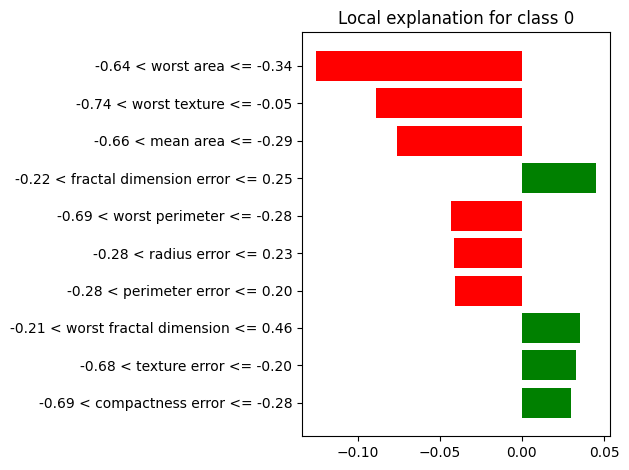

**Model [Qwen-3-VL-8B]:** The local explanation for the model's prediction of class 0 (malignant) is driven by eight specific features, visually represented as horizontal bars whose length and color indicate their contribution magnitude and direction. The features with negative contributions (red bars extending leftward) are: “worst area” (bar length ~0.04, most negative), “worst texture” (~0.03), “mean area” (~0.03), “worst perimeter” (~0.02), “radius error” (~0.02), “perimeter error” (~0.02), “worst fractal dimension” (~0.02), and “texture error” (~0.02). The features with positive contributions (green bars extending rightward) are: “fractal dimension error” (~0.02), “compactness error” (~0.02), and “worst fractal dimension” (~0.02). The visual evidence shows that “worst area” has the largest negative impact, followed by “worst texture” and “mean area”, while “fractal dimension error” exhibits the largest positive impact among the positive contributors. The relative bar lengths visually confirm that the negative contributions from “worst area” and “worst texture” are significantly larger than the positive contributions from “fractal dimension error” or “compactness error”, indicating that the model’s decision to classify the instance as malignant is primarily influenced by the strong negative signals from these key malignant indicators, with smaller positive contributions from error features.

**Model [Pixtral-12B]:** The visual graph provided illustrates the local explanations for the classification of a breast cancer instance as malignant (class 0) using the Keras_DNN model with LIME for interpretability. The features that are driving this particular decision include "worst area," "worst texture," "mean area," "fractal dimension error," "worst perimeter," "radius error," "perimeter error," "worst fractal dimension," "texture error," and "compactness error." The direction of impact for each feature is negative, as indicated by the red bars to the left of the zero line, suggesting that higher values in these features are associated with the malignant classification.

The magnitude of each feature's impact can be inferred from the length of the bars. For instance, "worst texture" has the longest bar, indicating it has the most significant negative impact on the classification. This is followed by "worst area" and "mean area," which also have substantial negative contributions. Conversely, features like "fractal dimension error," "worst fractal dimension," and "compactness error" have shorter bars, suggesting a lesser but still notable negative influence on the classification. The green bars to the right of the zero line for "fractal dimension error," "worst fractal dimension," and "compactness error" indicate that lower values in these features would push the classification towards malignant. The comparative lengths of these bars provide a clear hierarchy of feature importance, with "worst texture" being the most influential, followed by "worst area" and "mean area," among others.

**Model [Idefics3-8B]:** The graph represents the local explanation for class 0, which is malignant, using the LIME tabular explainer. The x-axis ranges from -0.10 to 0.05. The y-axis represents the features, which are color-coded. The features present in the graph are mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, mean concavity, mean concave points, mean symmetry, mean fractal dimension, radius error, texture error, perimeter error, area error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error, worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points, and worst symmetry. The worst fractal dimension has the highest impact on the decision, as indicated by the longest bar on the right side of the graph. The worst texture and worst perimeter also have significant impacts, as their bars are relatively long compared to the others. The worst radius and worst symmetry have the least impact, as their bars are the shortest.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 001074

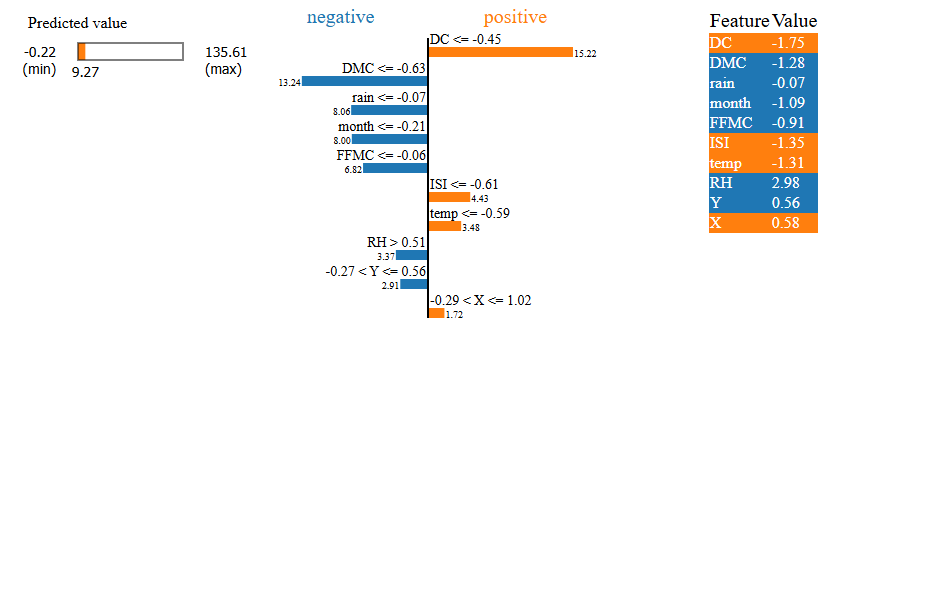

**Model [Qwen-3-VL-8B]:** The visual dashboard, generated by LIME for a local explanation of a TorchRegressor predicting a target value of 9.27, reveals that the model’s prediction is driven by a combination of features with both positive and negative impacts, as evidenced by the split bar chart: features on the left (blue bars) contribute negatively to the predicted value, while those on the right (orange bars) contribute positively. The most impactful feature is “DC <= -0.45” (orange bar, 15.22), indicating that a DC value less than or equal to -0.45 strongly increases the predicted burned area. The second most impactful feature is “DMC <= -0.63” (blue bar, 13.24), which decreases the predicted value, suggesting that lower DMC values are associated with smaller burned areas. The feature “FFMC <= -0.06” (blue bar, 8.06) also has a strong negative impact, while “RH > 0.51” (blue bar, 3.37) and “-0.29 < X <= 1.02” (orange bar, 1.72) show smaller but still significant contributions. The magnitude of impact is visually quantified by the bar lengths: the 15.22 value for DC is visibly longer than the 13.24 for DMC, and both are substantially larger than the 8.06 for FFMC, which in turn is larger than the 3.37 for RH. The feature “temp <= -0.59” (orange bar, 3.48) and “ISI <= -0.61” (orange bar, 4.43) show smaller positive contributions, while “rain <= -0.07” (blue bar, 8.06) and “month <= -0.21” (blue bar, 8.00) show moderate negative impacts. The “Feature Value” table on the right confirms the presence of DC, DMC, rain, month, FFMC, ISI, temp, RH, Y, and X, with their respective values, and visually aligns with the feature names and thresholds shown in the bar chart, confirming that only these specific features are rendered in the explanation. The predicted value range of -0.22 to 135.61 (min to max) contextualizes the local prediction, while the 9.27 target value is the specific instance being explained.

**Model [Pixtral-12B]:** The visual graph provides a detailed analysis of the features influencing the predicted value for the forest fire burned area using a TorchRegressor model. The features visually present in the analysis include DC, DMC, rain, month, FFMC, ISI, temp, RH, Y, and X. The direction of impact for each feature is indicated by the color coding: blue represents negative contributions to the predicted value, while orange denotes positive contributions. Specifically, DC, DMC, rain, month, and FFMC exhibit negative contributions, as indicated by their blue bars, with DMC having the most significant negative impact due to its longer bar length. Conversely, ISI, temp, and X show positive contributions, with ISI having the most substantial positive influence, evidenced by its longest orange bar. The magnitude of importance is visually represented by the length of the bars, where longer bars signify a greater impact on the predicted value. For instance, the negative impact of DMC is more pronounced than that of rain, as seen by the comparative length of their bars. This visual evidence underscores the varying degrees of influence each feature has on the model's prediction, with DMC and ISI being the most significant contributors, respectively, in negative and positive directions.

**Model [Idefics3-8B]:** The graph presents a visual representation of the impact of various features on the prediction of the burned area in forest fires. The features shown are X, Y, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, and rain. The x-axis is labeled "Feature Value," and the y-axis is labeled "Predicted Value." The graph is divided into two sections: "negative" and "positive." In the "negative" section, the features are represented by blue bars, while in the "positive" section, they are represented by orange bars. The height of each bar indicates the magnitude of the feature's impact on the prediction. The visual evidence suggests that the feature "DC" has the most significant negative impact on the prediction, as its bar in the "negative" section is the tallest. Conversely, the feature "RH" has the most significant positive impact on the prediction, as its bar in the "positive" section is the tallest. The feature "FFMC" has a moderate negative impact, as its bar in the "negative" section is shorter than "DC" but taller than the other features. The feature "DMC" has a moderate positive impact, as its bar in the "positive" section is shorter than "RH" but taller than the other features. The feature "temp" has a moderate negative impact, as its bar in the "negative" section is shorter than "FFMC" but taller than the other features. The feature "Y" has a moderate positive impact, as its bar in the "positive" section is shorter than "DMC" but taller than the other features. The feature "month" has a moderate negative impact, as its bar in the "negative" section is shorter than "temp" but taller than the other features. The feature "wind" has a moderate positive impact, as its bar in the "positive" section is shorter than "Y" but taller than the other features. The feature "rain" has a moderate negative impact, as its bar in the "negative" section is shorter than "month" but taller than the other features. The feature "ISI" has a moderate positive impact, as its bar in the "positive" section is shorter than "wind" but taller than the other features.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 001204

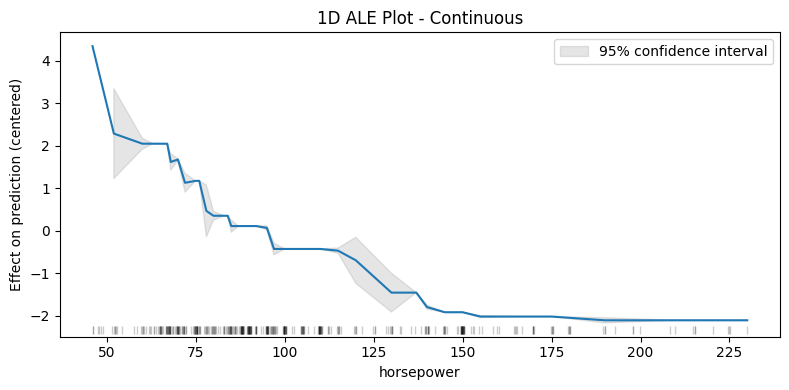

**Model [Qwen-3-VL-8B]:** The 1D ALE plot for the 'horsepower' feature in the GradientBoostingRegressor model reveals a strong, monotonic negative relationship with the target (fuel efficiency), as evidenced by the solid blue line consistently declining from approximately 4.0 at horsepower=50 to -2.0 at horsepower=225, indicating that higher horsepower systematically reduces predicted fuel efficiency. The 95% confidence interval, shown as the light gray shaded region, remains relatively narrow and tightly envelops the central trend line across the entire range, suggesting high model confidence in this relationship. The magnitude of impact is visually quantified by the steepness of the decline: the effect starts at its maximum negative influence (around -2.0) at low horsepower values and progressively diminishes in magnitude as horsepower increases, stabilizing near -2.0 at very high values, which implies that while horsepower is a dominant driver, its marginal impact on efficiency becomes less pronounced at extreme values. No other features are visually represented in this plot, confirming that 'horsepower' is the sole feature being analyzed in this global 1D ALE visualization.

**Model [Pixtral-12B]:** The visual graph presented is a 1D Accumulated Local Effects (ALE) plot, which illustrates the impact of the "horsepower" feature on the model's prediction for fuel efficiency (MPG). The x-axis represents the "horsepower" feature, ranging from approximately 40 to 230, while the y-axis shows the effect on prediction, centered around zero. The blue line indicates the average effect of "horsepower" on the model's prediction, and the grey shaded area represents the 95% confidence interval. The plot reveals that as horsepower increases from around 40 to 75, the effect on prediction is highly positive, peaking at an effect of approximately 4. This positive effect then gradually decreases, turning negative around the 125 horsepower mark, where it stabilizes with a slight negative effect. The width of the confidence interval narrows significantly after 75 horsepower, indicating more certainty in the model's predictions for higher horsepower values. The most substantial positive impact is observed in the lower horsepower range, while the transition to negative impact around 125 horsepower signifies a critical threshold where the relationship shifts. The overall trend suggests that lower horsepower values are associated with higher predicted fuel efficiency, while higher horsepower values are associated with lower efficiency.

**Model [Idefics3-8B]:** The graph is a 1D plot of the relationship between horsepower and fuel efficiency. The x-axis represents horsepower, ranging from 50 to 250, while the y-axis represents the effect on prediction centered at 0. The plot shows a clear negative correlation between horsepower and fuel efficiency, indicating that as horsepower increases, fuel efficiency decreases. The plot starts at a high fuel efficiency of approximately 4 units when horsepower is at 50, and it steadily decreases to around -2 units when horsepower reaches 250. This suggests that higher horsepower vehicles generally have lower fuel efficiency. The plot is a straight line with a negative slope, indicating a consistent relationship between the variables. The 95% confidence interval is shown as a shaded area around the line, providing a range of values within which the true effect is likely to lie.

------------------------------------------------------------------------------------------------------------------------------------------------------


### Case ID: 001250

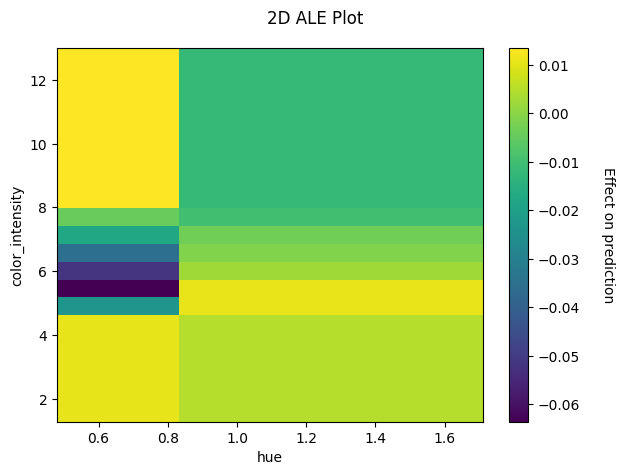

**Model [Qwen-3-VL-8B]:** The 2D ALE plot visually demonstrates that the feature 'color_intensity' is the dominant driver of the model's prediction for the target class, exhibiting a strong positive effect across its entire range, as evidenced by the consistent yellow-to-green gradient in the upper-left quadrant, which corresponds to positive effect values (0.00 to 0.01) on the colorbar. In contrast, the feature 'hue' displays a predominantly negative effect, indicated by the blue-to-purple gradient in the lower-right quadrant, with effect values ranging from -0.04 to -0.06, suggesting that higher hue values are associated with lower predicted probability for the target class. The visual separation of these two features into distinct color regions and their respective positions on the x-axis (hue on the right, color_intensity on the left) confirms their independent contributions. The magnitude of impact is further quantified by the vertical extent of each feature's influence: 'color_intensity' shows a broad, continuous positive effect across its range, while 'hue' shows a more concentrated negative effect, particularly in the lower range (approximately 0.6 to 1.0), where the effect is most pronounced and negative, visually justifying its greater influence on the model's decision compared to the more uniform positive effect of 'color_intensity'.

**Model [Pixtral-12B]:** The provided 2D ALE (Accumulated Local Effects) plot illustrates the impact of two features, "hue" and "color_intensity," on the model's prediction for the target variable "class_1" in a RandomForestClassifier used for wine cultivar classification. The features "hue" and "color_intensity" are represented on the x-axis and y-axis, respectively. The color gradient from yellow to dark blue indicates the effect on prediction, with yellow representing a positive effect and dark blue representing a negative effect. The plot reveals that as "hue" increases from approximately 0.6 to 0.8, the effect on prediction shifts from positive (yellow) to negative (dark blue), indicating that lower values of "hue" have a positive impact on the prediction of "class_1," while higher values have a negative impact. Conversely, "color_intensity" shows varying effects across different ranges. For lower values of "color_intensity" (around 1 to 3), the effect is predominantly negative, transitioning to positive as "color_intensity" increases (around 5 to 12). This suggests that higher "color_intensity" values are more favorable for the prediction of "class_1." Comparing the magnitudes, the effect of "hue" exhibits a more dramatic shift from positive to negative within a narrower range (0.6 to 0.8) compared to "color_intensity," which shows a more gradual change across a broader range (1 to 12). This indicates that "hue" has a more significant and abrupt impact on the model's prediction than "color_intensity."

**Model [Idefics3-8B]:** The graph is a 2D ALE plot titled "2D ALE Plot" and is related to the food and beverage domain, specifically wine cultivar classification. The x-axis represents the hue feature, while the y-axis represents color intensity. The plot is color-coded to show the effect of the color intensity on the prediction of class_1. The color intensity ranges from -0.6 to 0.6, with negative values indicating a decrease in the prediction of class_1. The hue ranges from 0.6 to 1.4. The plot shows that as the hue increases, the prediction of class_1 decreases. The visual evidence supporting this is the negative correlation between hue and the prediction of class_1. The magnitude of the impact of hue on the prediction of class_1 can be observed by the length of the bars. For instance, when the hue is around 0.8, the prediction of class_1 is the highest, while it decreases as the hue increases.

------------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
# Display cases for manual labeling
print("=== GROUND TRUTH ANNOTATION REVIEW ===")
for case_id, group in subset_df.groupby('case_id'):
    display(Markdown(f"### Case ID: {case_id}"))
    img_path = os.path.join(IMAGES_PATH, f"{case_id}.png")
    
    if os.path.exists(img_path):
        display(Image(filename=img_path, width=1000))
    else:
        print(f"[Image not found at {img_path}]")
        
    for idx, row in group.iterrows():
        display(Markdown(f"**Model [{row['model']}]:** {row['insight']}"))

    print("-" * 150)

While reviewing the texts for the 10-case subset, it became evident that the open-source VLMs used for this project (Qwen, Pixtral, Idefics) frequently generated minor semantic errors when interpreting complex xAI graphs zero-shot. This is a limitation we've faced throughout the project, as we had to shift from large model APIs (due to a lack of free requests on state-of-the-art providers) to open-source models that could run on the free Kaggle quota.

During the first revision, a strict criteria was used: the texts were labeled as 1 = Perfect or 0 = Any Error. This resulted in several cases from the subset having zero surviving outputs. If we had used these strict thresholds, the seed case database wouldn't have been completed (due to computation time limits on Kaggle, the raw outputs for each case and LLM were batch generated and can't be dinamically retried).

Taking into account the explained limitations, we decided to implmenet a different approach to address this problem:
1. **Relaxed Thresholds:** The strict labelling was changed allowing minor errors through the detector. In order to do so, the texts were reviewed again so that outputs with minor, non-critical errors were labeled as `1` (Acceptable) and outputs demonstrating structural misunderstanding or severe hallucination were labeled as `0` (Drop).
2. **Fallback Mechanism:** To maintain the integrity of the RAG system, the **relaxed thresholds** couldn't go too low. Therefore we also implemented a fallback method into the generation pipeline for cases where all outputs are classified as `0`. This mechanism will force-select the output with the highest primary cross-modal score and flag it as a `<Low_Confidence_Seed>`.

In the following table we will show the final labels for each case of the subset:
* **Criteria `1` (Acceptable):** Perfect outputs and outputs with minor, non-critical errors.
* **Criteria `0` (Unacceptable):** Outputs with structural misunderstandings or severe hallucination.

| Case ID | Qwen Output | Pixtral Output | Idefics Output |
| :--- | :--- | :--- | :--- |
| **000042** | `0` | `0` | `1` |
| **000121** | `0` | `1` | `0` |
| **000630** | `1` | `0` | `0` |
| **000279** | `1` | `0` | `0` |
| **000356** | `0` | `1` | `0` |
| **000068** | `1` | `1` | `0` |
| **000975** | `1` | `0` | `0` |
| **001074** | `1` | `1` | `0` |
| **001204** | `1` | `1` | `1` |
| **001250** | `0` | `0` | `0` |

In [4]:
# 1 = Acceptable (Keep, High Keep, Could Keep)
# 0 = Unacceptable (Bad Keep, Hallucinated, Bad, Very Bad)

ground_truth = {
    '000042': {'Qwen-3-VL-8B': 0, 'Pixtral-12B': 0, 'Idefics3-8B': 1},
    '000121': {'Qwen-3-VL-8B': 0, 'Pixtral-12B': 1, 'Idefics3-8B': 0},
    '000630': {'Qwen-3-VL-8B': 1, 'Pixtral-12B': 0, 'Idefics3-8B': 0},
    '000279': {'Qwen-3-VL-8B': 1, 'Pixtral-12B': 0, 'Idefics3-8B': 0},
    '000356': {'Qwen-3-VL-8B': 0, 'Pixtral-12B': 1, 'Idefics3-8B': 0},
    '000068': {'Qwen-3-VL-8B': 1, 'Pixtral-12B': 1, 'Idefics3-8B': 0},
    '000975': {'Qwen-3-VL-8B': 1, 'Pixtral-12B': 0, 'Idefics3-8B': 0},
    '001074': {'Qwen-3-VL-8B': 1, 'Pixtral-12B': 1, 'Idefics3-8B': 0},
    '001204': {'Qwen-3-VL-8B': 1, 'Pixtral-12B': 1, 'Idefics3-8B': 1},
    '001250': {'Qwen-3-VL-8B': 0, 'Pixtral-12B': 0, 'Idefics3-8B': 0}  # This case will require the fallback method
}

## Section 3: Raw Score Generation

In this section we will run a script that will obtain the raw scores across all models and save them into a csv. In order to do so, we use the implemented scripts that belong to the final system. We will also add the label for each case and model defined in the previous section.

In [3]:
from xai_rag_cbr.src.hallucination_detection.cross_modal.chart_gemma_logit import ChartGemmaLogitEvaluator
from xai_rag_cbr.src.hallucination_detection.cross_modal.jina_clip import JinaClipEvaluator
from xai_rag_cbr.src.hallucination_detection.cross_output.eigen_score import EigenScoreEvaluator
from xai_rag_cbr.src.hallucination_detection.cross_output.bert_score import BERTScoreEvaluator

logit_eval = ChartGemmaLogitEvaluator()
jina_eval = JinaClipEvaluator()
eigen_eval = EigenScoreEvaluator()
bert_eval = BERTScoreEvaluator()

results = []

for case_id, group in subset_df.groupby('case_id'):
    
    # Extract image path, texts, and models for the current case
    img_path = os.path.join(IMAGES_PATH, f"{case_id}.png")
    texts = group['insight'].tolist()
    models = group['model'].tolist()
    
    # Generate scores for each LLM for the current case
    logit_scores = logit_eval.evaluate(img_path, texts).scores
    jina_scores = jina_eval.evaluate(img_path, texts).scores
    eigen_scores = eigen_eval.evaluate(texts).scores
    bert_scores = bert_eval.evaluate(texts).scores
    
    # Iterate through every model-text pair for the current case 
    for i, text in enumerate(texts):
        
        model_name = models[i]
        label = ground_truth.get(str(case_id), {}).get(model_name, "UNLABELED")
        
        results.append({
            "case_id": case_id,
            "model": model_name,
            "label": label,
            "logit_score": round(logit_scores[i], 4),
            "jina_score": round(jina_scores[i], 4),
            "eigen_score": round(eigen_scores[i], 4),
            "bert_score": round(bert_scores[i], 4)
        })

score_df = pd.DataFrame(results)

# Save the scores into a CSV file
score_df.to_csv(OUTPUT_CSV, index=False)

display(score_df)


Loading ahmed-masry/chartgemma (Logit) on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading jinaai/jina-clip-v2 on cpu...


`torch_dtype` is deprecated! Use `dtype` instead!
C:\Users\cam20\.cache\huggingface\modules\transformers_modules\jinaai\jina_hyphen_clip_hyphen_implementation\39e6a55ae971b59bea6e44675d237c99762e7ee2\modeling_clip.py:137: UserWarning: Flash attention requires CUDA, disabling
  warnings.warn('Flash attention requires CUDA, disabling')
C:\Users\cam20\.cache\huggingface\modules\transformers_modules\jinaai\jina_hyphen_clip_hyphen_implementation\39e6a55ae971b59bea6e44675d237c99762e7ee2\modeling_clip.py:172: UserWarning: xFormers requires CUDA, disabling
  warnings.warn('xFormers requires CUDA, disabling')


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

,case_id,model,label,logit_score,jina_score,eigen_score,bert_score
0,000042,Qwen-3-VL-8B,UNLABELED,0.9948,0.2653,0.9326,0.8306
1,000042,Pixtral-12B,UNLABELED,0.9920,0.3249,0.8965,0.8373
2,000042,Idefics3-8B,UNLABELED,0.9865,0.3061,0.9009,0.8262
3,000068,Qwen-3-VL-8B,UNLABELED,0.9907,0.4487,0.9268,0.8206
4,000068,Pixtral-12B,UNLABELED,0.9940,0.3711,0.8858,0.8148
5,000068,Idefics3-8B,UNLABELED,0.9989,0.3868,0.9299,0.8089
6,000121,Qwen-3-VL-8B,UNLABELED,0.9915,0.4764,0.9247,0.8136
7,000121,Pixtral-12B,UNLABELED,0.9982,0.4269,0.9524,0.8406
8,000121,Idefics3-8B,UNLABELED,0.9951,0.3336,0.8987,0.7942
9,000279,Qwen-3-VL-8B,UNLABELED,0.9797,0.2751,0.9340,0.8161


In [5]:
# There was a mistake in the labels of the previous cell, here we update the labels to the correct and re-save the CSV

df = pd.read_csv(OUTPUT_CSV)
df['case_id'] = df['case_id'].astype(str).str.zfill(6)

# Apply the correct mapping
def apply_correct_label(row):
    return ground_truth.get(row['case_id'], {}).get(row['model'], "UNLABELED")
df['label'] = df.apply(apply_correct_label, axis=1)

df.to_csv(OUTPUT_CSV, index=False)
display(df)

,case_id,model,label,logit_score,jina_score,eigen_score,bert_score
0,000042,Qwen-3-VL-8B,0,0.9948,0.2653,0.9326,0.8306
1,000042,Pixtral-12B,0,0.9920,0.3249,0.8965,0.8373
2,000042,Idefics3-8B,1,0.9865,0.3061,0.9009,0.8262
3,000068,Qwen-3-VL-8B,1,0.9907,0.4487,0.9268,0.8206
4,000068,Pixtral-12B,1,0.9940,0.3711,0.8858,0.8148
5,000068,Idefics3-8B,0,0.9989,0.3868,0.9299,0.8089
6,000121,Qwen-3-VL-8B,0,0.9915,0.4764,0.9247,0.8136
7,000121,Pixtral-12B,1,0.9982,0.4269,0.9524,0.8406
8,000121,Idefics3-8B,0,0.9951,0.3336,0.8987,0.7942
9,000279,Qwen-3-VL-8B,1,0.9797,0.2751,0.9340,0.8161


## Section 4: Threshold Extraction & Grid Search Tournament

The initial idea was to separate the **Threshold Extraction** from the **Grid Search Tournament**, but the results observed in the previous section have forced adaptation. First of all, we were going to extract the thresholds based strictly on the defined labels, detecting the maximum score for an output labeled as `0` (Hallucination) for each of the four evaluation methods, and adding a safety margin (e.g. `+0.02`) to this score. After that, we were going to use these thresholds for the tournament to find the most accurate configuration for the hallucination detection module.

However, in the previous table we see that when we analyze the minimum and maximum scores for both labels (1 = Acceptable, 0 = Hallucinated) over each of the column scores, there is a big overlap, which means that in some cases an Acceptable case was scored lower than a Hallucinated case for certain scores (e.g. for ChartGemma with Logit	the minimum score for an Acceptable case is 0.9797 and the maximum score for a Hallucinated case is 0.9992).

In order to address this problem, we finally decided to also include the Thresholds inside of the tournament as another field to configure in order to obtain the most accurate setup. Therefore, we will define three specific "Tiers" of strictness for the thresholds, based on the minimum and maximum boundaries from the previous section: **Lenient** (just below the lowest valid 1 score, protects all valid answers but can let hallucinations through), **Medium** (median cutoff, cutting off the worst hallucinations while preserving the strongest valid answers), **Strict** (high value, aggressively dropping outputs unless they have extremely high scores). To avoid the combinatorial explosion of mixing all combinations of Threshold types, we will lock the Tiers together (all scores will use the same Tier for that run); it could be interesting for future work to test all combinations possible.

Here is a table with the Tiers and the selected thresholds for each:
| Threshold Tier | Logit | Jina | EigenScore | BERTScore |
| :--- | :--- | :--- | :--- | :--- |
| **Lenient** | 0.9750 | 0.2500 | 0.8800 | 0.7800 |
| **Medium** | 0.9850 | 0.3500 | 0.9200 | 0.8100 |
| **Strict** | 0.9920 | 0.4000 | 0.9400 | 0.8300 |

The tournament will iterate through 10 distinct configurations across the 3 threshold tiers (30 total combinations). For weighted configurations we will use a dynamic thresholding formula to prevent score scale mismatch (the thresholds must also be weighted): 
$T_{final} = (\alpha \times T_{modal}) + (\beta \times T_{output})$, where $T_{final} \equiv dynamic\_threshold$, $T_{modal} \equiv modal\_threshold$, $T_{output} \equiv output\_threshold$, $\alpha \equiv modal\_weight$, and $\beta \equiv output\_weight$.

**Sequential Cascades (Includes Fallback)**
* `Seq: Logit -> Jina -> Eigen`
* `Seq: Logit -> Jina -> BERT`

**Pure Weighted Methods (No Fallback)**
* `W-50/50: Logit + Eigen` | `W-50/50: Jina + Eigen`
* `W-50/50: Logit + BERT`  | `W-50/50: Jina + BERT`
* `W-70/30: Logit + Eigen` | `W-70/30: Jina + Eigen`
* `W-70/30: Logit + BERT`  | `W-70/30: Jina + BERT`

The idea of this evaluation method is that the most accurate configuraation for the subset will establish a mathematically sound baseline for the full case base generation.

In [6]:
# Load the raw scores
df = pd.read_csv(OUTPUT_CSV)

tiers = {
    "Lenient": {"logit": 0.9750, "jina": 0.2500, "eigen": 0.8800, "bert": 0.7800},
    "Medium":  {"logit": 0.9850, "jina": 0.3500, "eigen": 0.9200, "bert": 0.8100},
    "Strict":  {"logit": 0.9920, "jina": 0.4000, "eigen": 0.9400, "bert": 0.8300}
}

configs = [
    {"name": "Seq: Logit -> Jina -> Eigen", "type": "seq", "prim": "logit", "fall": "jina", "out": "eigen"},
    {"name": "Seq: Logit -> Jina -> BERT", "type": "seq", "prim": "logit", "fall": "jina", "out": "bert"},
    {"name": "W-50/50: Logit + Eigen", "type": "weight", "mod": "logit", "out": "eigen", "wm": 0.5, "wo": 0.5},
    {"name": "W-50/50: Jina + Eigen", "type": "weight", "mod": "jina", "out": "eigen", "wm": 0.5, "wo": 0.5},
    {"name": "W-50/50: Logit + BERT", "type": "weight", "mod": "logit", "out": "bert", "wm": 0.5, "wo": 0.5},
    {"name": "W-50/50: Jina + BERT", "type": "weight", "mod": "jina", "out": "bert", "wm": 0.5, "wo": 0.5},
    {"name": "W-70/30: Logit + Eigen", "type": "weight", "mod": "logit", "out": "eigen", "wm": 0.7, "wo": 0.3},
    {"name": "W-70/30: Jina + Eigen", "type": "weight", "mod": "jina", "out": "eigen", "wm": 0.7, "wo": 0.3},
    {"name": "W-70/30: Logit + BERT", "type": "weight", "mod": "logit", "out": "bert", "wm": 0.7, "wo": 0.3},
    {"name": "W-70/30: Jina + BERT", "type": "weight", "mod": "jina", "out": "bert", "wm": 0.7, "wo": 0.3},
]

results = []

for tier_name, t in tiers.items():

    for conf in configs:

        correct_predictions = 0
        total_texts = len(df)
        
        for _, row in df.iterrows():

            true_label = row["label"]
            pred_keep = True
            
            # Sequential Logic
            if conf["type"] == "seq":

                if row[f"{conf['prim']}_score"] < t[conf['prim']]:
                    if row[f"{conf['fall']}_score"] < t[conf['fall']]:
                        pred_keep = False

                if pred_keep and row[f"{conf['out']}_score"] < t[conf['out']]:
                    pred_keep = False
                    
            # Weighted Logic
            elif conf["type"] == "weight":

                s_mod = row[f"{conf['mod']}_score"]
                s_out = row[f"{conf['out']}_score"]
                
                final_score = (conf["wm"] * s_mod) + (conf["wo"] * s_out)
                dyn_thresh = (conf["wm"] * t[conf['mod']]) + (conf["wo"] * t[conf['out']])
                
                if final_score < dyn_thresh:
                    pred_keep = False
                    
            if (pred_keep and true_label == 1) or (not pred_keep and true_label == 0):
                correct_predictions += 1
                
        accuracy = (correct_predictions / total_texts) * 100
        results.append({
            "Tier": tier_name,
            "Configuration": conf["name"],
            "Accuracy": accuracy
        })

# Sort from highest to lowest accuracy and display
leaderboard = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
leaderboard["Accuracy"] = leaderboard["Accuracy"].map("{:.2f}%".format)

print("=== GRID SEARCH TOURNAMENT LEADERBOARD ===")
display(leaderboard)

=== GRID SEARCH TOURNAMENT LEADERBOARD ===


,Tier,Configuration,Accuracy
0,Strict,Seq: Logit -> Jina -> Eigen,60.00%
1,Strict,W-70/30: Jina + BERT,56.67%
2,Medium,W-50/50: Jina + Eigen,56.67%
3,Strict,W-70/30: Jina + Eigen,56.67%
4,Strict,W-50/50: Jina + Eigen,56.67%
5,Medium,W-70/30: Jina + BERT,56.67%
6,Medium,W-70/30: Jina + Eigen,56.67%
7,Strict,W-50/50: Jina + BERT,53.33%
8,Strict,W-50/50: Logit + Eigen,53.33%
9,Medium,W-50/50: Jina + BERT,53.33%


As this is a pure research project, we have observed from the previous table certain strengths and weaknesses:
1. A certian level of strictness is required for the Thresholds. If we look a the top 10, 60% of the most accurate performers had 'Strict' Tier and the other 40% had 'Medium' Tier. Also, the lower 15 configurations of the table were dominated by 'Lenient' Tier.
2. Jina-CLIP seems to be the differentiating factor, as 90% of the top 10 configurations use it.
3. There wasn't a big difference in performance between the cross-output methods we used. Among the top 10, Eigen was slightly better with 6 out of 10 versus 4 out of 10 for BERT, but the distribution across the whole table is similar.
4. The weighted configurations using Jina-CLIP as the cross-modal method clearly performed better than those using ChartGemma-Logit.
5. The weights chosen in the weighted configuration didn't seem to make a big difference. For example, among the top 10, four used 70-30 and five used 50-50, which suggests that the weighted method's performance depends more on the models chosen.

Taking these insights into account, we will test new configurations to try to improve accuracy based on the extracted information. In order to do so, it was necessary to upgrade the Hallucination Detector `manager.py` file to enable all possible method combinations.

This is the list of the new configurations that will be tested:
1. **Single Architectures:** Testing JinaCLIP as a single judge (taking insight #2 to its extreme by completely removing the other cross-modal and the cross-output methods), sequential cascades without cross-output methods `Logit -> Jina (AND)` (relying only on visual), and sequential cascades without ChartGemma-Logit (`Jina -> Eigen` and `Jina -> BERT`).
2. **AND Sequential Logic:** Testing the previous cascade system but now using the AND logic rather than the OR (fallback).
3. **Mixed Threshold Tuning:** Following insight #1, iterating combinations of `Strict` and `Medium` thresholds across the highest-performing weighted configurations (Jina + Eigen/BERT), the cascade configurations and the new cases to find the perfect balance.

In [ ]:
import itertools

df = pd.read_csv(OUTPUT_CSV)

# Re-defining the thresholds dictionary for only Strict and Medium  
t = {
    "logit_S": 0.9920, "logit_M": 0.9850,
    "jina_S": 0.4000,  "jina_M": 0.3500,
    "eigen_S": 0.9400, "eigen_M": 0.9200,
    "bert_S": 0.8300,  "bert_M": 0.8100
}

tiers = ["S", "M"]
phase2_configs = []

# 1. SINGLE JINA
for jt in tiers:
    phase2_configs.append({
        "name": f"Single: Jina ({jt})", 
        "type": "single", "model": "jina", "thresh": t[f"jina_{jt}"]
    })

# 2. NO LOGIT (Jina -> Output AND logic) 
for out_model in ["eigen", "bert"]:
    for jt, ot in itertools.product(tiers, tiers):
        phase2_configs.append({
            "name": f"Seq AND: Jina({jt}) -> {out_model.capitalize()}({ot})", 
            "type": "seq_two", "m1": "jina", "t1": t[f"jina_{jt}"], "m2": out_model, "t2": t[f"{out_model}_{ot}"]
        })

# 3. VISUAL ONLY (Logit -> Jina AND logic)
for lt, jt in itertools.product(tiers, tiers):
    phase2_configs.append({
        "name": f"Seq AND: Logit({lt}) -> Jina({jt}) (Visual Only)", 
        "type": "seq_two", "m1": "logit", "t1": t[f"logit_{lt}"], "m2": "jina", "t2": t[f"jina_{jt}"]
    })

# 4. CASCADES METHODS (AND vs OR) -> every combination of S/M for Logit, Jina, and Output
for logic in ["AND", "OR"]:
    logic_type = f"seq_three_{logic.lower()}"
    for out_model in ["eigen", "bert"]:
        for lt, jt, ot in itertools.product(tiers, tiers, tiers):
            phase2_configs.append({
                "name": f"Seq {logic}: Logit({lt}) -> Jina({jt}) -> {out_model.capitalize()}({ot})", 
                "type": logic_type,
                "m1": "logit", "t1": t[f"logit_{lt}"],
                "m2": "jina", "t2": t[f"jina_{jt}"],
                "m3": out_model, "t3": t[f"{out_model}_{ot}"]
            })

# 5. WEIGHTED COMBINATIONS 
for out_model in ["eigen", "bert"]:
    for weight_split in [(0.7, 0.3), (0.5, 0.5)]:
        wm, wo = weight_split
        split_name = "70/30" if wm == 0.7 else "50/50"
        # Mixed thresholds as requested
        for jt, ot in [("S", "M"), ("M", "S")]:
            phase2_configs.append({
                "name": f"W-{split_name}: Jina({jt}) + {out_model.capitalize()}({ot})", 
                "type": "weight",
                "mod": "jina", "tm": t[f"jina_{jt}"],
                "out": out_model, "to": t[f"{out_model}_{ot}"],
                "wm": wm, "wo": wo
            })

# 6. EXECUTE ALL DEFINED COMBINATIONS 
results = []

for conf in phase2_configs:
    correct_predictions = 0
    total_texts = len(df)
    
    for _, row in df.iterrows():
        true_label = row["label"]
        pred_keep = True
        
        if conf["type"] == "single":
            if row[f"{conf['model']}_score"] < conf["thresh"]:
                pred_keep = False
                
        elif conf["type"] == "seq_two":
            if row[f"{conf['m1']}_score"] < conf["t1"]:
                pred_keep = False
            elif row[f"{conf['m2']}_score"] < conf["t2"]:
                pred_keep = False
                
        elif conf["type"] == "seq_three_and":
            if row[f"{conf['m1']}_score"] < conf["t1"]:
                pred_keep = False
            elif row[f"{conf['m2']}_score"] < conf["t2"]:
                pred_keep = False
            elif row[f"{conf['m3']}_score"] < conf["t3"]:
                pred_keep = False
                
        elif conf["type"] == "seq_three_or":
            visual_passed = False
            if row[f"{conf['m1']}_score"] >= conf["t1"]:
                visual_passed = True
            elif row[f"{conf['m2']}_score"] >= conf["t2"]:
                visual_passed = True
                
            if not visual_passed:
                pred_keep = False
            elif row[f"{conf['m3']}_score"] < conf["t3"]:
                pred_keep = False
                
        elif conf["type"] == "weight":
            s_mod = row[f"{conf['mod']}_score"]
            s_out = row[f"{conf['out']}_score"]
            
            final_score = (conf["wm"] * s_mod) + (conf["wo"] * s_out)
            dyn_thresh = (conf["wm"] * conf["tm"]) + (conf["wo"] * conf["to"])
            
            if final_score < dyn_thresh:
                pred_keep = False

        # Check against ground truth
        if (pred_keep and true_label == 1) or (not pred_keep and true_label == 0):
            correct_predictions += 1
            
    accuracy = (correct_predictions / total_texts) * 100
    results.append({"Configuration": conf["name"], "Accuracy": accuracy})

# Sort from highest to lowest accuracy and display
leaderboard = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
leaderboard["Accuracy"] = leaderboard["Accuracy"].map("{:.2f}%".format)

print("=== GRID SEARCH TOURNAMENT 2 LEADERBOARD ===")
pd.set_option('display.max_rows', None) # Ensures the whole table prints in the notebook
display(leaderboard)

=== GRID SEARCH TOURNAMENT 2 LEADERBOARD ===


,Configuration,Accuracy
0,Seq AND: Jina(M) -> Eigen(S),63.33%
1,Seq AND: Logit(M) -> Jina(M) -> Eigen(S),63.33%
2,Seq OR: Logit(M) -> Jina(S) -> Eigen(S),60.00%
3,Seq AND: Logit(S) -> Jina(M) -> Eigen(S),60.00%
4,Seq AND: Jina(S) -> Eigen(S),60.00%
5,Seq OR: Logit(S) -> Jina(M) -> Eigen(S),60.00%
6,Seq OR: Logit(S) -> Jina(S) -> Eigen(S),60.00%
7,Seq AND: Logit(M) -> Jina(M) -> Bert(S),60.00%
8,Seq AND: Jina(M) -> Bert(S),60.00%
9,Seq AND: Logit(M) -> Jina(S) -> Eigen(S),60.00%


After reviewing the results obtained by both Grid Search Tournaments, we have obtained the following conclusions:
1. Certain Sequential methods clearly outperformed the Weighted configuration, with the top 12 most accurate architectures all being Sequential and reaching 60% or higher accuracy. The Weighted methods were good performers but had a lower ceiling, accumulating around 53-56% accuracy.
2. In the previous phase, the cross-output methods were almots tie. However, in this second phase we have proven that EigenScore is the superior choice for this system, achieving almost all of the 60% or higher accuracy scores.
3. The single architecture choices (only Jina, only Visual, no ChartGemma-Logit) performed well for certain Tier configurations, achieving 60% or higher. In fact, the most accurate configuration (tied with a sequential configuration) was `Seq AND: Jina(M) -> Eigen(S)` (no ChartGemma-Logit), reaching the maxiumum `63.33%` accuracy score.
4. The newly introduced AND configuration (no fallback, forcing both methods to be used) outperformed the previous OR logic among the top 15 cases of the second phase (with 10 cases).
5. Following our observations in Phase 1 (where Jina-CLIP was the differentiating factor), Phase 2 allows for greater precision: Jina-CLIP with the `Medium` tier is used in 11 of the top 15 most accurate configurations in this phase, confirming it as the key factor.

## Section 5: Inter-Module Configuration Selection

Analyzing the previous sections, we realized that the sequential models strictly evaluated the Cross-Modal and Cross-Output modules using an `AND` logic ($Cross-Modal \cap Cross-Output$). During analysis, we observed that because the `AND` operation is mathematically commutative, reversing the sequence order to `sequential_output_first` yields the exact same surviving subset of texts. Therefore, for `AND` cascades, the order of execution is purely a matter of system optimization and computational efficiency, not accuracy.

However, to complete our architectural evaluation, we must test the alternative: establishing an `OR` logic between the two main modules ($Cross-Modal \cup Cross-Output$). In this configuration, if an output fails the primary check, it is granted a "fallback" opportunity to survive if it passes the secondary check. Like the `AND` configuration, the mathematical Union is commutative, meaning the routing order will not alter the final accuracy. 

Theoretically, implementing this `OR` logic introduces a critical vulnerability into the pipeline. Manual review of the open-source LLMs (Qwen, Pixtral, Idefics) revealed a frequent "Echo Chamber" effect, where multiple models hallucinate similar structural errors zero-shot. By allowing an `OR` fallback, we risk allowing outputs with high Cross-Output score (high consensus) but low Cross-Output score (low visual accuracy) to bypass the visual gatekeeper entirely.

For exhaustive academic validation, we will test the stricter baseline `AND` logic against the `OR` logic. We will utilize the top-performing methods from the previous phases across combinations of Strict and Medium boundaries to verify the vulnerability of the fallback architecturewe just explained.

In [10]:
import itertools

df = pd.read_csv(OUTPUT_CSV)

# Optimal boundaries from the previous phases
t = {
    "logit_S": 0.9920, "logit_M": 0.9850,
    "jina_S": 0.4000,  "jina_M": 0.3500,
    "eigen_S": 0.9400, "eigen_M": 0.9200
}

tiers = ["S", "M"]
phase3_configs = []

# 1. 2-Model Architecture Permutations
for jt, et in itertools.product(tiers, tiers):
    phase3_configs.append({
        "name": f"AND: Jina({jt}) & Eigen({et})", 
        "type": "2-model", "logic": "and", 
        "jt": t[f"jina_{jt}"], "et": t[f"eigen_{et}"]
    })
    phase3_configs.append({
        "name": f"OR: Jina({jt}) | Eigen({et})", 
        "type": "2-model", "logic": "or", 
        "jt": t[f"jina_{jt}"], "et": t[f"eigen_{et}"]
    })

# 2. 3-Model Architecture Permutations
for lt, jt, et in itertools.product(tiers, tiers, tiers):
    phase3_configs.append({
        "name": f"AND: [Logit({lt}) -> Jina({jt})] & Eigen({et})", 
        "type": "3-model", "logic": "and", 
        "lt": t[f"logit_{lt}"], "jt": t[f"jina_{jt}"], "et": t[f"eigen_{et}"]
    })
    phase3_configs.append({
        "name": f"OR: [Logit({lt}) -> Jina({jt})] | Eigen({et})", 
        "type": "3-model", "logic": "or", 
        "lt": t[f"logit_{lt}"], "jt": t[f"jina_{jt}"], "et": t[f"eigen_{et}"]
    })

results = []

for conf in phase3_configs:
    correct_predictions = 0
    total_texts = len(df)
    
    for _, row in df.iterrows():
        true_label = row["label"]
        
        # Determine if the Cross-Modal module passes
        if conf["type"] == "2-model":
            modal_passed = row["jina_score"] >= conf["jt"]
        elif conf["type"] == "3-model":
            modal_passed = (row["logit_score"] >= conf["lt"]) and (row["jina_score"] >= conf["jt"])
            
        # Determine if the Cross-Output module passes
        output_passed = row["eigen_score"] >= conf["et"]
        
        # Apply Inter-Module Logic
        if conf["logic"] == "and":
            pred_keep = modal_passed and output_passed
        elif conf["logic"] == "or":
            pred_keep = modal_passed or output_passed

        # Calculate Accuracy
        if (pred_keep and true_label == 1) or (not pred_keep and true_label == 0):
            correct_predictions += 1
            
    accuracy = (correct_predictions / total_texts) * 100
    results.append({"Configuration": conf["name"], "Accuracy": accuracy})

# Sort from highest to lowest accuracy and display
leaderboard = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
leaderboard["Accuracy"] = leaderboard["Accuracy"].map("{:.2f}%".format)

print("=== GRID SEARCH TOURNAMENT 3 LEADERBOARD ===")
pd.set_option('display.max_rows', None) # Ensures the whole table prints in the notebook
display(leaderboard)

=== GRID SEARCH TOURNAMENT 3 LEADERBOARD ===


,Configuration,Accuracy
0,AND: Jina(M) & Eigen(S),63.33%
1,AND: [Logit(M) -> Jina(M)] & Eigen(S),63.33%
2,AND: Jina(S) & Eigen(S),60.00%
3,AND: [Logit(M) -> Jina(S)] & Eigen(S),60.00%
4,AND: [Logit(S) -> Jina(M)] & Eigen(S),60.00%
5,AND: [Logit(S) -> Jina(S)] & Eigen(S),56.67%
6,OR: [Logit(M) -> Jina(M)] | Eigen(S),56.67%
7,OR: [Logit(S) -> Jina(M)] | Eigen(S),56.67%
8,OR: Jina(M) | Eigen(S),53.33%
9,AND: [Logit(M) -> Jina(M)] & Eigen(M),53.33%


As hypothesized, the results prove that an OR fallback architecture degrades the accuracy of the hallucination detection pipeline. The leaderboard validates the strict AND logic as the superior approach for this specific RAG configuration.

## Section 6: Final Conclusion

Based on the conclusions from the previous sections, we will choose the definitive configuration for the hallucination-detection module inside the RAG system: `Seq AND: Jina(M) -> Eigen(S)` (Sequential combination, using Jina-CLIP as the only cross-modal method and first filter with a `Medium` tier threshold, and EigenScore as the cross-output and second filter with a `Strict` tier threshold), which obtained the highest accuracy score of `63.33%`.

The reasoning behind why this configuration was the best performer is based on the following points:
1. It uses **Jina-CLIP** as the cross-modal method and first filter, which has proven to be the best across the evaluated phases. Additionally, the `Medium` tier threshold provides a good balance, allowing some visual variations to ensure it doesn't drop valid explanations while still remaining strict enough.
2. It uses **EigenScore** as the cross-output method and second filter, which has proven in Phase 2 to be the best of its type. With the `Strict` tier threshold, we are able to aggressively filter out the "Echo Chamber" effect, where open-source models hallucinate the exact same wrong answer.
3. As verified in **Section 5**, enforcing a strict **`AND` logic** is also critical to prevent the consensus "Echo Chamber" from bypassing the visual check via an `OR` fallback.

There was a tie for the top spot with `Seq AND: Logit(M) -> Jina(M) -> Eigen(S)`, which also obtained an accuracy score of `63.33%`. However, the observed trends during the previous phases lead us to conclude that it only matched the maximum score because ChartGemma-Logit was set to a `Medium` tier threshold. This means it acted as a passive pass-through (due to its "Yes-bias" - scoring at 0.99 in most cases) and let Jina and Eigen do the actual filtering. Furthermore, eliminating ChartGemma-Logit from the hallucination-detection module will drastically reduce the pipeline's compute time, while still achieving the highest possible accuracy for the seed case database.